In [ ]:
import os
import json
from google.colab import files

print("📂 Please upload your kaggle.json file")
uploaded = files.upload()

# Create kaggle folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ kaggle.json is set up!")


📂 Please upload your kaggle.json file


Saving kaggle.json to kaggle.json
✅ kaggle.json is set up!


In [ ]:
!rm -rf "New Plant Diseases Dataset(Augmented)"

print("⬇️ Downloading dataset from Kaggle...")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

print("📦 Unzipping...")
!unzip -q new-plant-diseases-dataset.zip
print("✅ Dataset Extracted Successfully!")


⬇️ Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.69G/2.70G [00:17<00:00, 223MB/s]
100% 2.70G/2.70G [00:17<00:00, 163MB/s]
📦 Unzipping...
✅ Dataset Extracted Successfully!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Dropout,MaxPooling2D,Flatten
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

base_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(base_dir, "train")
VALID_DIR = os.path.join(base_dir, "valid")

print("TRAIN DIR:", TRAIN_DIR)
print("VALID DIR:", VALID_DIR)

print("Train folders:", os.listdir(TRAIN_DIR)[:5])
print("Valid folders:", os.listdir(VALID_DIR)[:5])


TRAIN DIR: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
VALID DIR: /content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Train folders: ['Corn_(maize)___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Early_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Septoria_leaf_spot']
Valid folders: ['Corn_(maize)___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Early_blight', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Tomato___Septoria_leaf_spot']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=128,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(150, 150),
    batch_size=128,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(150, 150),
    batch_size=128,
    class_mode='categorical'
)


Found 56251 images belonging to 38 classes.
Found 14044 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [ ]:
# Display the 38 unique class names (labels) each one in seperated line
for label,index in train_generator.class_indices.items():
    print(index," : ",label)


0  :  Apple___Apple_scab
1  :  Apple___Black_rot
2  :  Apple___Cedar_apple_rust
3  :  Apple___healthy
4  :  Blueberry___healthy
5  :  Cherry_(including_sour)___Powdery_mildew
6  :  Cherry_(including_sour)___healthy
7  :  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8  :  Corn_(maize)___Common_rust_
9  :  Corn_(maize)___Northern_Leaf_Blight
10  :  Corn_(maize)___healthy
11  :  Grape___Black_rot
12  :  Grape___Esca_(Black_Measles)
13  :  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14  :  Grape___healthy
15  :  Orange___Haunglongbing_(Citrus_greening)
16  :  Peach___Bacterial_spot
17  :  Peach___healthy
18  :  Pepper,_bell___Bacterial_spot
19  :  Pepper,_bell___healthy
20  :  Potato___Early_blight
21  :  Potato___Late_blight
22  :  Potato___healthy
23  :  Raspberry___healthy
24  :  Soybean___healthy
25  :  Squash___Powdery_mildew
26  :  Strawberry___Leaf_scorch
27  :  Strawberry___healthy
28  :  Tomato___Bacterial_spot
29  :  Tomato___Early_blight
30  :  Tomato___Late_blight
31  :  T

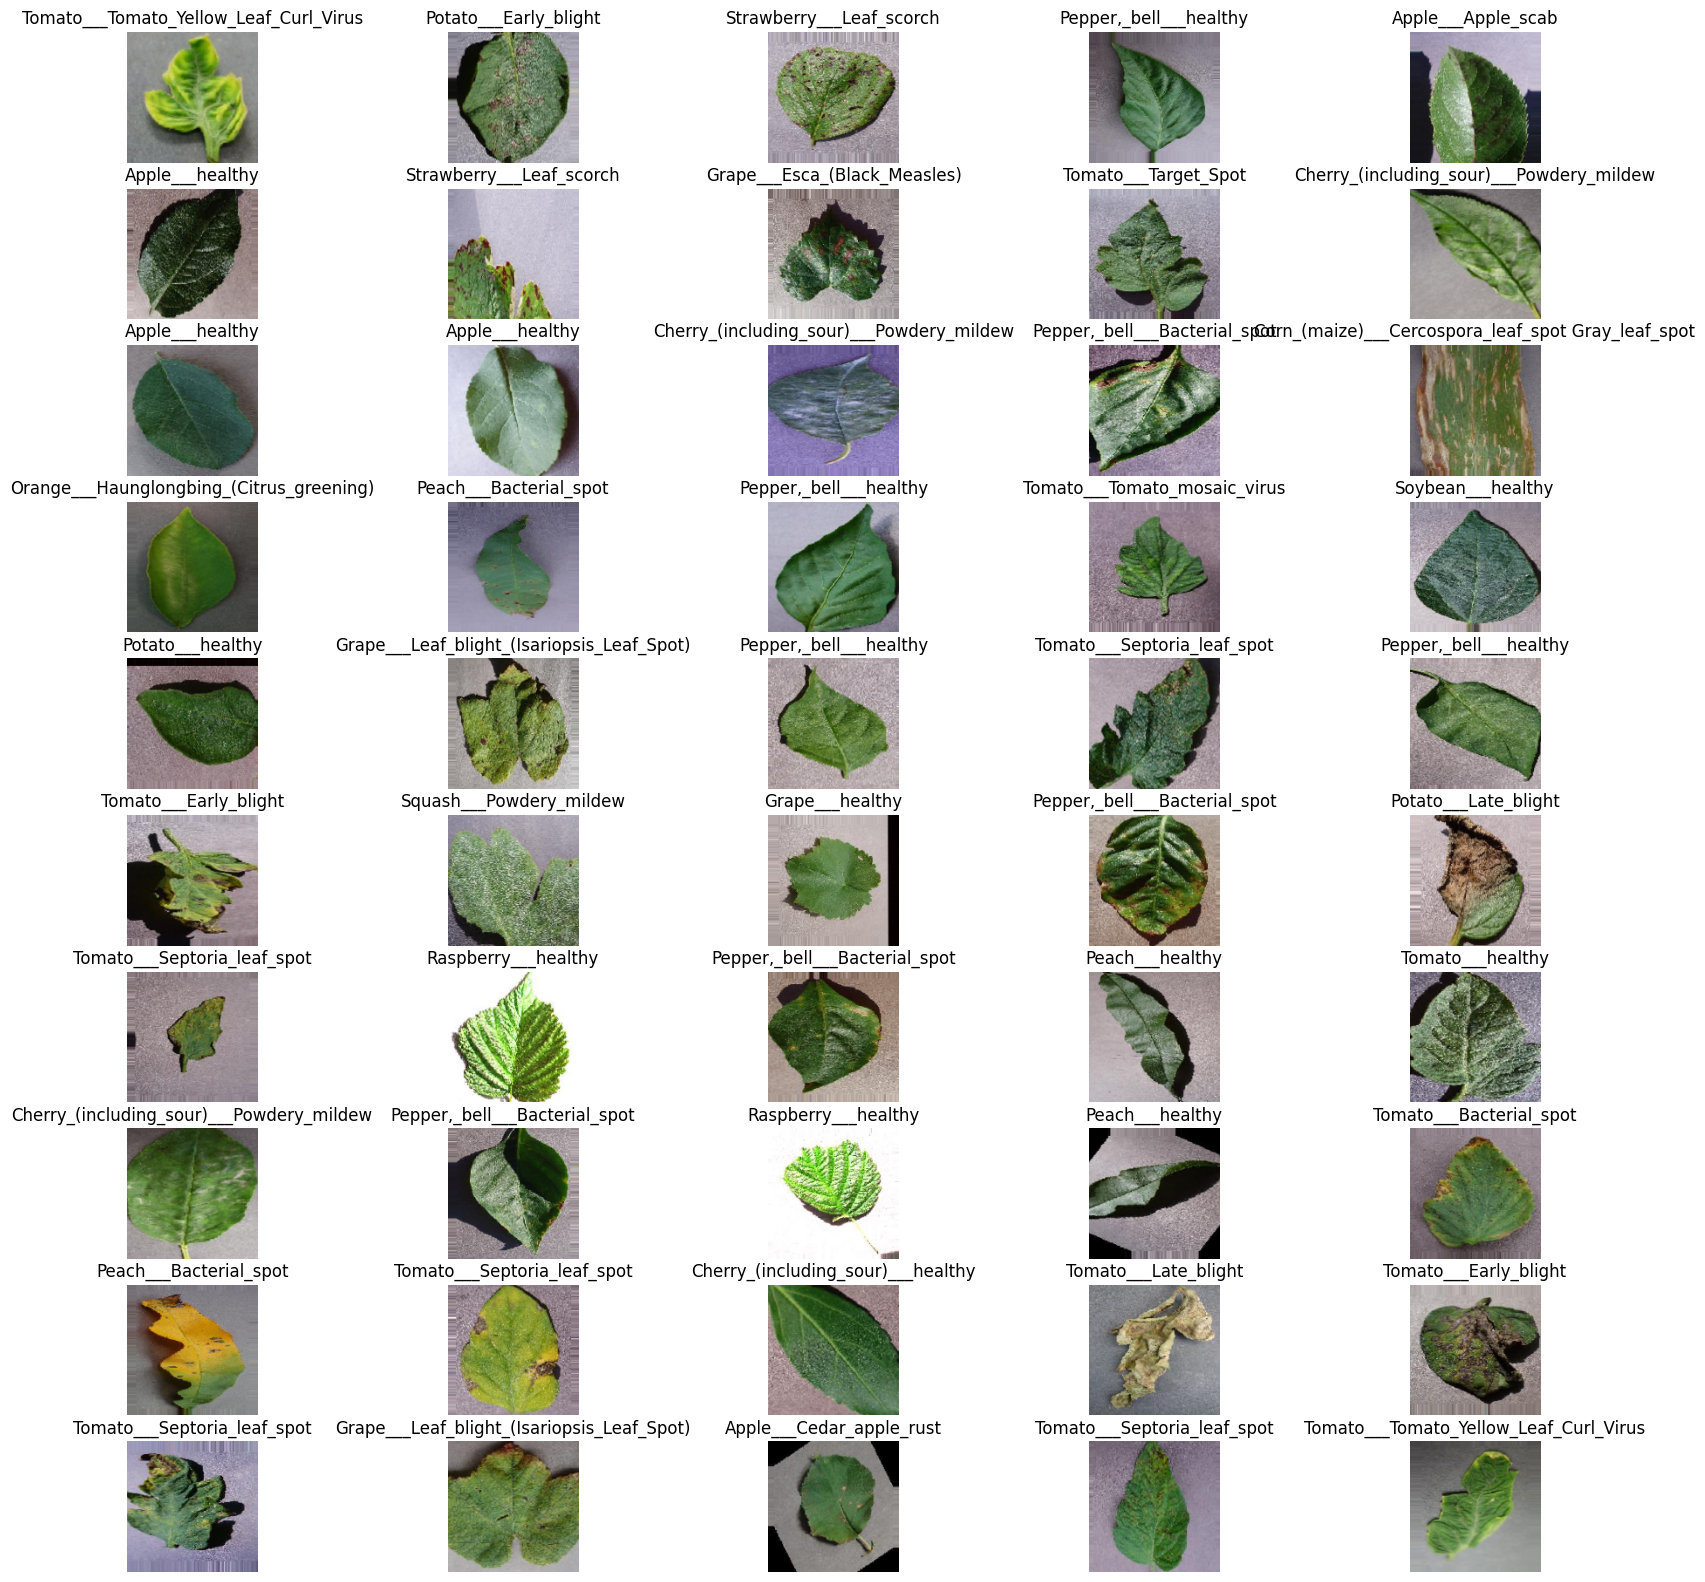

In [ ]:
# Get a batch of images and labels from the train_generator
images, labels = next(train_generator)  # Get the next batch (128 images in this case)

# Reverse the class_indices dictionary to get a mapping from index to class name
class_labels = {v: k for k, v in train_generator.class_indices.items()}

# Convert one-hot encoded labels back to the index form (if using categorical mode)
label_indices = np.argmax(labels, axis=1)

# If you want to shuffle the batch and display 50 random images
random_indices = np.random.choice(len(images), 50, replace=False)  # Choose 50 random indices

# Plot 50 random images with labels
plt.figure(figsize=(20, 20))
for i, idx in enumerate(random_indices):
    plt.subplot(10, 5, i + 1)  # Create a grid of 5 rows and 10 columns
    plt.imshow(images[idx])
    plt.title(class_labels[label_indices[idx]])  # Show the label as the title
    plt.axis('off')  # Hide the axis

plt.show()

In [ ]:
model=Sequential([
  # Input Layer in CNN
  Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),



  # Feture Extraction Layers in CNN with MaxPooling
  Conv2D(32,(3,3),activation='relu'),
  MaxPooling2D((2,2)),
  Conv2D(64,(3,3),activation='relu'),
  MaxPooling2D((2,2)),
  Conv2D(128,(3,3),activation='relu'),
  MaxPooling2D((2,2)),
  Conv2D(256,(3,3),activation='relu'),
  MaxPooling2D((2,2)),
  Conv2D(512,(3,3),activation='relu'),
  MaxPooling2D((2,2)),


# Fully Connected Neural Network
  Flatten(),
  Dense(512, activation='relu'),
  Dropout(0.5),
  Dense(38, activation='softmax')  # 38 classes

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,646,406 (10.10 MB)

 Trainable params: 2,646,406 (10.10 MB)

 Non-trainable params: 0 (0.00 B)

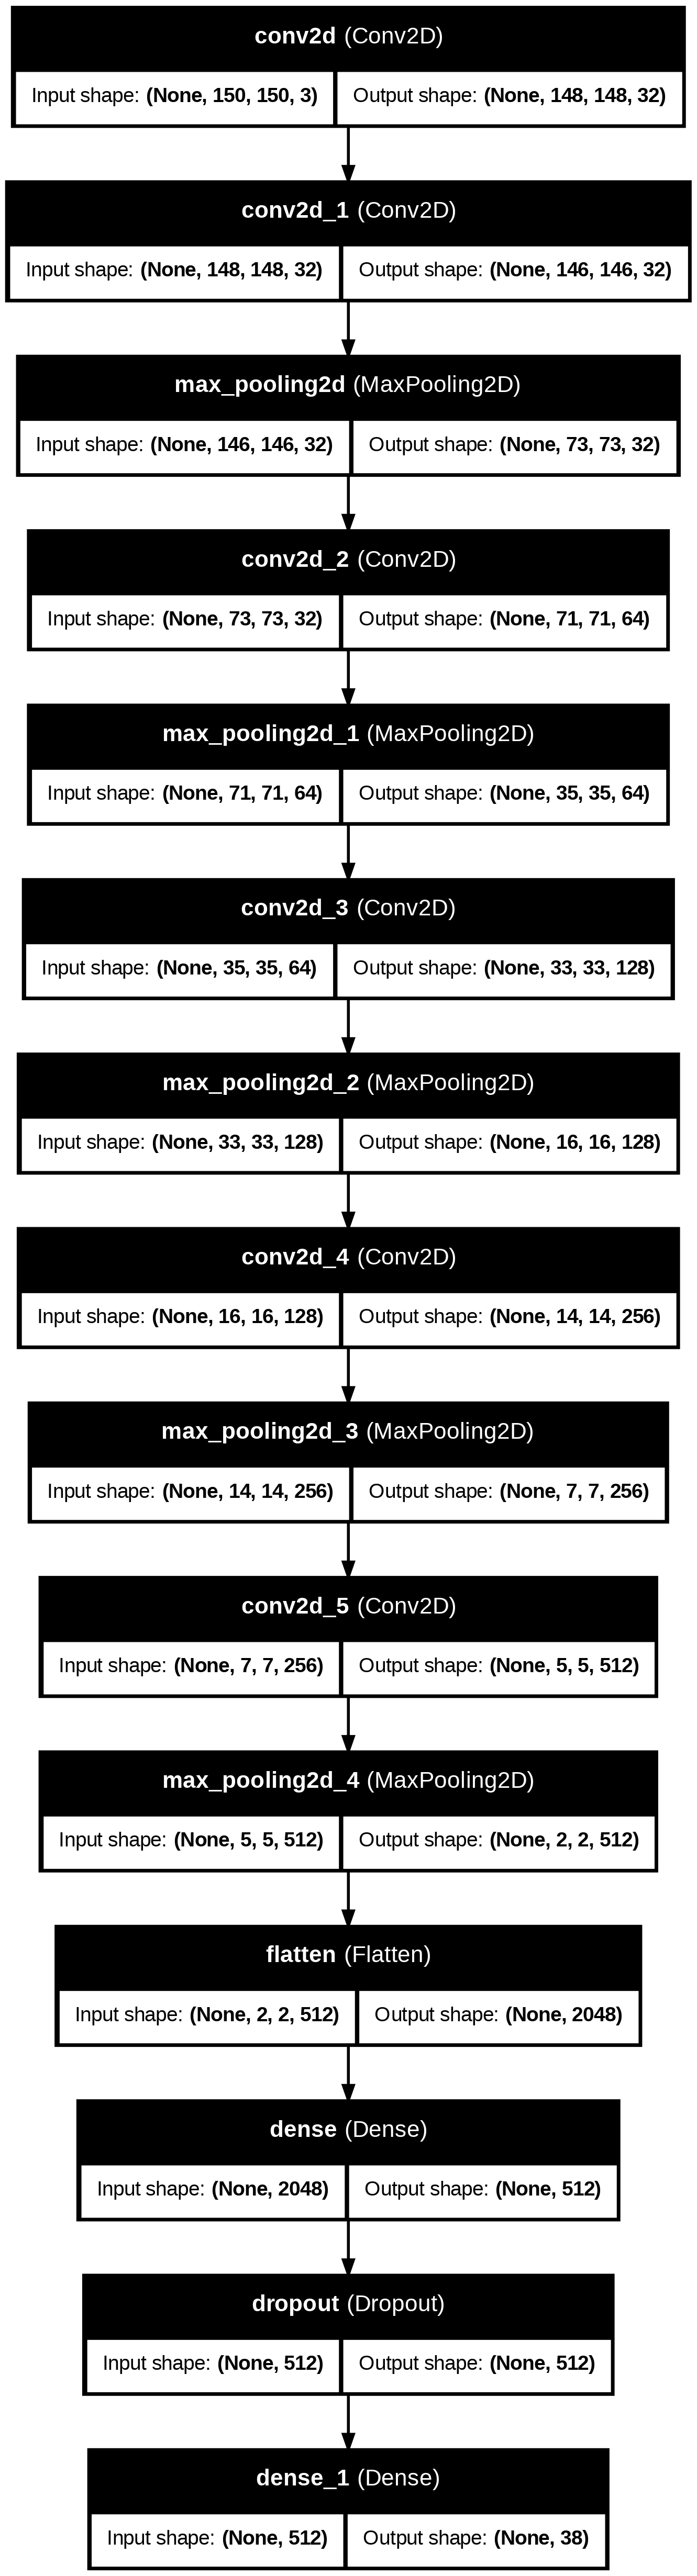

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
from tensorflow.keras import metrics
model.compile(optimizer='adam',loss='categorical_crossentropy'
              ,metrics=['accuracy',metrics.Recall(),metrics.Precision()])

In [ ]:
early_stopping=EarlyStopping(monitor='val_loss',patience=5)
model_checkpoint=ModelCheckpoint(
    'best_model.keras',  # File path where the model will be saved
    monitor='val_loss',  # Metric to monitor
    save_best_only=True,  # Save only the model with the best validation loss
    mode='min',  # 'min' because lower loss is better
    verbose=1  # Verbosity mode
)

In [ ]:
import json

# Save class names from generator
class_indices = train_generator.class_indices

with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)

print("✅ class_indices.json saved!")
print(class_indices)


✅ class_indices.json saved!
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato

In [ ]:
history=model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=50,
    callbacks=[early_stopping,model_checkpoint],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.1391 - loss: 3.1204 - precision: 0.6410 - recall: 0.0359
Epoch 1: val_loss improved from inf to 1.48845, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 472s 1s/step - accuracy: 0.1394 - loss: 3.1191 - precision: 0.6411 - recall: 0.0361 - val_accuracy: 0.5477 - val_loss: 1.4884 - val_precision: 0.7615 - val_recall: 0.3486
Epoch 2/50
  1/439 ━━━━━━━━━━━━━━━━━━━━ 1:42 233ms/step - accuracy: 0.5000 - loss: 1.5391 - precision: 0.6774 - recall: 0.3281

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 1.48845 to 1.46694, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 139s 316ms/step - accuracy: 0.5000 - loss: 1.5391 - precision: 0.6774 - recall: 0.3281 - val_accuracy: 0.5506 - val_loss: 1.4669 - val_precision: 0.7704 - val_recall: 0.3513
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.6022 - loss: 1.2889 - precision: 0.7755 - recall: 0.4512
Epoch 3: val_loss improved from 1.46694 to 0.67504, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 434s 988ms/step - accuracy: 0.6023 - loss: 1.2884 - precision: 0.7756 - recall: 0.4514 - val_accuracy: 0.7818 - val_loss: 0.6750 - val_precision: 0.8631 - val_recall: 0.7052
Epoch 4/50
  1/439 ━━━━━━━━━━━━━━━━━━━━ 1:42 235ms/step - accuracy: 0.7188 - loss: 0.7690 - precision: 0.8416 - recall: 0.6641
Epoch 4: val_loss improved from 0.67504 to 0.62276, saving model to best_model.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 187ms/step - accuracy: 0.7188 - loss: 0.7690 - precis

In [ ]:
# using max to use best model saved by modelcheckpoint
train_accuracy = max(history.history['accuracy'])
val_accuracy = max(history.history['val_accuracy'])

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Training Accuracy: 0.9688
Validation Accuracy: 0.9495


In [ ]:
results = model.evaluate(test_generator)
loss = results[0]
accuracy = results[1]
precision = results[2]
recall = results[3]

print(f'Testing Loss: {loss}')
print(f'Testing Accuracy: {accuracy}')
print(f'Testing Precision: {precision}')
print(f'Testing Recall: {recall}')

138/138 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.9426 - loss: 0.1734 - precision: 0.9506 - recall: 0.9368
Testing Loss: 0.1724623739719391
Testing Accuracy: 0.943375825881958
Testing Precision: 0.9370020627975464
Testing Recall: 0.9509096145629883


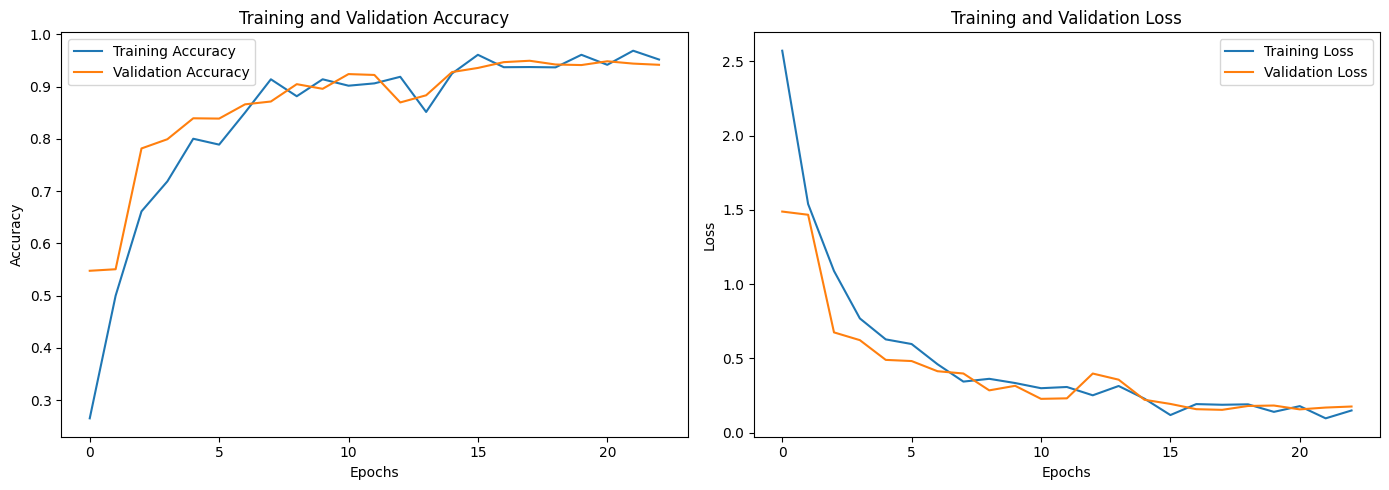

In [ ]:

import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns for subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot training and validation accuracy
axs[0].plot(history.history['accuracy'], label='Training Accuracy')
axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()

# Plot training and validation loss
axs[1].plot(history.history['loss'], label='Training Loss')
axs[1].plot(history.history['val_loss'], label='Validation Loss')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [ ]:
# Get predictions on the validation set
y_probs = model.predict(validation_generator)   # probabilities for each class
y_pred = np.argmax(y_probs, axis=1)             # pick highest probability class


110/110 ━━━━━━━━━━━━━━━━━━━━ 89s 805ms/step


110/110 ━━━━━━━━━━━━━━━━━━━━ 79s 720ms/step


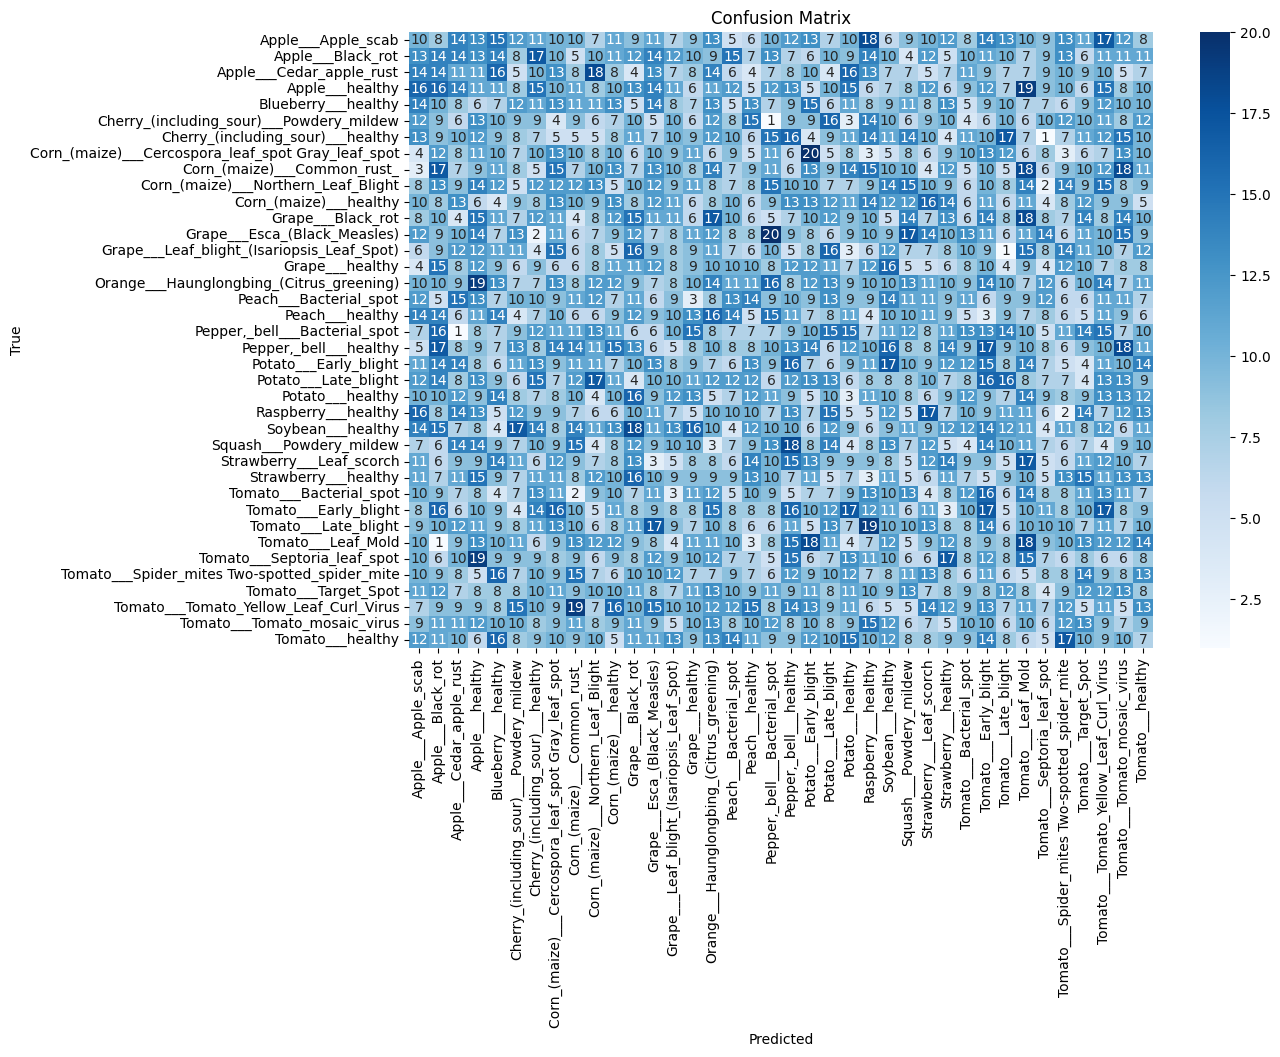

Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.03      0.02      0.03       403
                                 Apple___Black_rot       0.03      0.04      0.03       397
                          Apple___Cedar_apple_rust       0.03      0.03      0.03       352
                                   Apple___healthy       0.03      0.03      0.03       401
                               Blueberry___healthy       0.02      0.02      0.02       363
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       336
                 Cherry_(including_sour)___healthy       0.02      0.02      0.02       365
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.03      0.04      0.04       328
                       Corn_(maize)___Common_rust_       0.02      0.02      0.02       381
               Corn_(maize)___Northern_Leaf_Blight     

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get predictions
y_probs = model.predict(validation_generator)   # probabilities
y_pred = np.argmax(y_probs, axis=1)             # predicted labels
y_true = validation_generator.classes           # true labels

# Step 2: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = list(validation_generator.class_indices.keys())

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Step 3: Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))


In [ ]:
def Evaluate_model(model, train_generator, validation_generator, test_generator):
    model_evaluate_train = model.evaluate(train_generator)
    print("Loss       : ", model_evaluate_train[0])
    print("Accuracy   : ", model_evaluate_train[1])
    print("Precision  : ", model_evaluate_train[2])
    print("Recall     : ", model_evaluate_train[3])


    model_evaluate_valid = model.evaluate(validation_generator)
    print("Loss       : ", model_evaluate_valid[0])
    print("Accuracy   : ", model_evaluate_valid[1])
    print("Precision  : ", model_evaluate_valid[2])
    print("Recall     : ", model_evaluate_valid[3])


    model_evaluate_test = model.evaluate(test_generator)
    print("Loss       : ", model_evaluate_test[0])
    print("Accuracy   : ", model_evaluate_test[1])
    print("Precision  : ", model_evaluate_test[2])
    print("Recall     : ", model_evaluate_test[3])

    return np.round(model_evaluate_train[0], 2), np.round(model_evaluate_test[0], 2), \
           np.round(model_evaluate_train[1], 2), np.round(model_evaluate_test[1], 2), \
           np.round(model_evaluate_train[2], 2), np.round(model_evaluate_test[2], 2), \
           np.round(model_evaluate_train[3], 2), np.round(model_evaluate_test[3], 2)

In [ ]:
Final_Report = []

Final_Report.append(Evaluate_model(model, train_generator, validation_generator, test_generator))

440/440 ━━━━━━━━━━━━━━━━━━━━ 328s 746ms/step - accuracy: 0.9695 - loss: 0.0922 - precision: 0.9739 - recall: 0.9651
Loss       :  0.09060098230838776
Accuracy   :  0.9692983031272888
Precision  :  0.9652094841003418
Recall     :  0.9735865592956543
110/110 ━━━━━━━━━━━━━━━━━━━━ 80s 729ms/step - accuracy: 0.9402 - loss: 0.1760 - precision: 0.9468 - recall: 0.9343
Loss       :  0.17742213606834412
Accuracy   :  0.9406864047050476
Precision  :  0.9343491792678833
Recall     :  0.9482583999633789
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 159ms/step - accuracy: 0.9450 - loss: 0.1670 - precision: 0.9541 - recall: 0.9398
Loss       :  0.17246240377426147
Accuracy   :  0.943375825881958
Precision  :  0.9370020627975464
Recall     :  0.9509096145629883


In [ ]:
model.save('Plant_Disease_Model.h5')
print("Model saved as 'plant_disease_model.h5'. Download this file for your web app!")

Model saved as 'plant_disease_model.h5'. Download this file for your web app!
